# Payment Pipeline — Data Quality Dashboard

Monitors three operational signals across the unified payment pipeline:
1. **Schema Compliance Rate** — what fraction of each source's rows passed both validation layers
2. **Data Freshness** — when was the last successfully ingested record per payment method
3. **Anomaly Detection** — volume anomalies, null rates, and amount outliers (single-snapshot)

**PLEASE: ensure to run the pipeline first before runnging this** 

## Section 0 — Setup & Data Load

In [28]:
import json
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
PARQUET_PATH = ROOT / "data" / "output" / "canonical_payments.parquet"
DLQ_PATH     = ROOT / "data" / "output" / "dead_letter_queue.json"
RAW_DIR      = ROOT / "data" / "raw"

if not PARQUET_PATH.exists() or not DLQ_PATH.exists():
    print("ERROR: pipeline output not found. Run `python src/pipeline.py` first.")
    sys.exit(1)

print(f"Parquet : {PARQUET_PATH}")
print(f"DLQ     : {DLQ_PATH}")

Parquet : /Users/ahmedothman/Desktop/mal/data/output/canonical_payments.parquet
DLQ     : /Users/ahmedothman/Desktop/mal/data/output/dead_letter_queue.json


In [29]:
# Load valid records
df_valid = duckdb.query(f"SELECT * FROM '{PARQUET_PATH}'").df()

# Load DLQ
df_dlq = pd.read_json(DLQ_PATH)

# Load raw CSVs
raw_csvs = {p.name: pd.read_csv(p) for p in sorted(RAW_DIR.glob("*.csv"))}

print(f"Valid records : {len(df_valid)}")
print(f"DLQ records   : {len(df_dlq)}")
print(f"Raw CSV files : {list(raw_csvs.keys())}")

Valid records : 294
DLQ records   : 6
Raw CSV files : ['bill_v1.csv', 'bill_v2.csv', 'card_v1.csv', 'card_v2.csv', 'transfer_v1.csv', 'transfer_v2.csv']


---
## Section 1 — Schema Compliance Rate

In [30]:
# Derive source_file from payment_method + version stored in source_metadata JSON
# Parentheses around ->>'version' prevent || from binding before the JSON extraction
valid_by_source = duckdb.query(f"""
    SELECT
        CASE payment_method
            WHEN 'CARD'     THEN 'card'
            WHEN 'TRANSFER' THEN 'transfer'
            WHEN 'BILL_PAY' THEN 'bill'
        END || '_' || (source_metadata->>'version') || '.csv' AS source_file,
        COUNT(*) AS valid_count
    FROM '{PARQUET_PATH}'
    GROUP BY source_file
    ORDER BY source_file
""").df()

dlq_by_source = (
    df_dlq.groupby("file").size().reset_index(name="dlq_count")
    .rename(columns={"file": "source_file"})
)

compliance = valid_by_source.merge(dlq_by_source, on="source_file", how="outer").fillna(0)
compliance["dlq_count"]   = compliance["dlq_count"].astype(int)
compliance["valid_count"] = compliance["valid_count"].astype(int)
compliance["total"]       = compliance["valid_count"] + compliance["dlq_count"]
compliance["compliance"]  = compliance["valid_count"] / compliance["total"]
compliance = compliance.sort_values("source_file").reset_index(drop=True)

display(compliance[["source_file", "valid_count", "dlq_count", "total", "compliance"]]
        .style.format({"compliance": "{:.1%}"}))

,source_file,valid_count,dlq_count,total,compliance
0,bill_v1.csv,48,2,50,96.0%
1,bill_v2.csv,50,0,50,100.0%
2,card_v1.csv,48,2,50,96.0%
3,card_v2.csv,50,0,50,100.0%
4,transfer_v1.csv,48,2,50,96.0%
5,transfer_v2.csv,50,0,50,100.0%


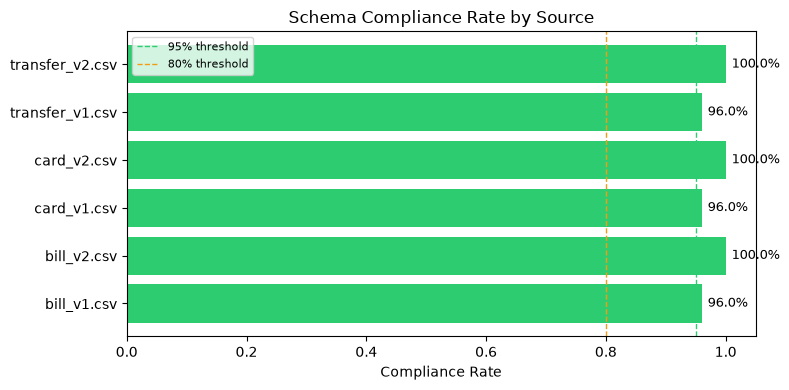

In [31]:
def compliance_color(rate):
    if rate >= 0.95: return "#2ecc71"   # green
    if rate >= 0.80: return "#f39c12"   # amber
    return "#e74c3c"                    # red

colors = [compliance_color(r) for r in compliance["compliance"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(compliance["source_file"], compliance["compliance"], color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Compliance Rate")
ax.set_title("Schema Compliance Rate by Source")
ax.axvline(0.95, color="#2ecc71", linestyle="--", linewidth=1, label="95% threshold")
ax.axvline(0.80, color="#f39c12", linestyle="--", linewidth=1, label="80% threshold")
for bar, rate in zip(bars, compliance["compliance"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1%}", va="center", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 2 — Data Freshness

In [32]:
freshness = duckdb.query(f"""
    SELECT
        payment_method,
        MAX(transaction_timestamp) AS last_seen,
        MIN(transaction_timestamp) AS first_seen,
        COUNT(*) AS record_count
    FROM '{PARQUET_PATH}'
    GROUP BY payment_method
    ORDER BY last_seen DESC
""").df()

# Staleness: hours since last_seen relative to the Parquet file's mtime (the pipeline run time)
run_time = pd.Timestamp(PARQUET_PATH.stat().st_mtime, unit="s", tz="UTC")
freshness["last_seen"] = pd.to_datetime(freshness["last_seen"], utc=True)
freshness["staleness_hrs"] = (run_time - freshness["last_seen"]).dt.total_seconds() / 3600

print(f"Pipeline last ran: {run_time.strftime('%Y-%m-%d %H:%M UTC')}\n")
for _, row in freshness.iterrows():
    print(f"{row['payment_method']:<12} last record: {str(row['last_seen'])[:19]}  "
          f"({row['staleness_hrs']:.0f}h ago)  records: {row['record_count']}")

Pipeline last ran: 2026-06-18 18:28 UTC

TRANSFER     last record: 2026-06-16 00:00:00  (66h ago)  records: 98
BILL_PAY     last record: 2026-06-16 00:00:00  (66h ago)  records: 98
CARD         last record: 2026-06-13 18:47:02  (120h ago)  records: 98


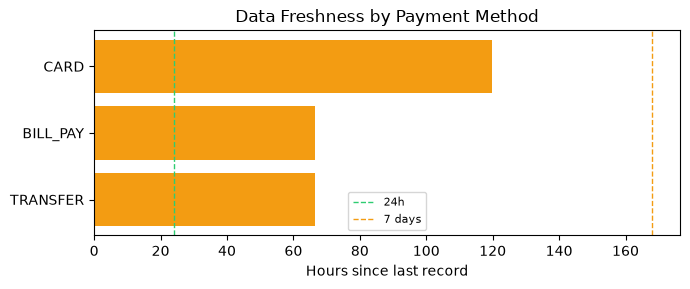

In [33]:
def freshness_color(hrs):
    if hrs < 24:   return "#2ecc71"
    if hrs < 168:  return "#f39c12"   # 1 week
    return "#e74c3c"

colors = [freshness_color(h) for h in freshness["staleness_hrs"]]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(freshness["payment_method"], freshness["staleness_hrs"], color=colors)
ax.set_xlabel("Hours since last record")
ax.set_title("Data Freshness by Payment Method")
ax.axvline(24,  color="#2ecc71", linestyle="--", linewidth=1, label="24h")
ax.axvline(168, color="#f39c12", linestyle="--", linewidth=1, label="7 days")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 3 — Anomaly Detection

### 3a — Volume Anomaly

In [34]:
EXPECTED_PER_SOURCE = 50
VOLUME_THRESHOLD    = 0.90   # flag if actual < 90% of expected

volume = compliance[["source_file", "total"]].copy()
volume["expected"]  = EXPECTED_PER_SOURCE
volume["pct"]       = volume["total"] / volume["expected"]
volume["alert"]     = volume["pct"] < VOLUME_THRESHOLD

alerts = volume[volume["alert"]]
if alerts.empty:
    print("No volume anomalies detected.")
else:
    print("VOLUME ALERTS:")
    for _, r in alerts.iterrows():
        print(f"  {r['source_file']}: {r['total']}/{r['expected']} rows ({r['pct']:.0%})")

No volume anomalies detected.


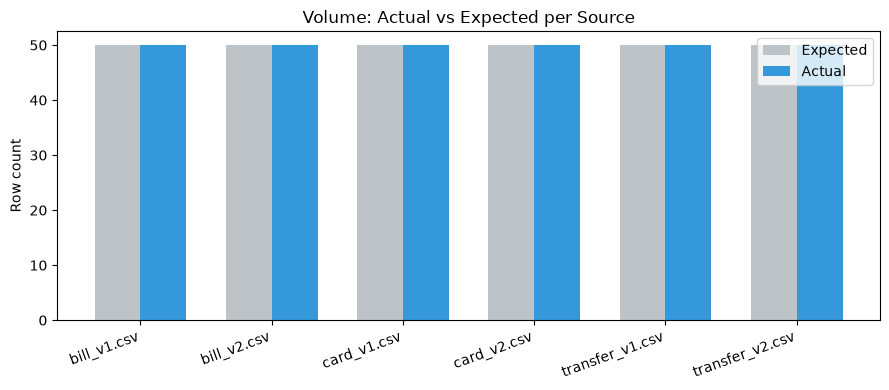

In [35]:
x = np.arange(len(volume))
width = 0.35
bar_colors = ["#e74c3c" if a else "#3498db" for a in volume["alert"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, volume["expected"], width, label="Expected", color="#bdc3c7")
ax.bar(x + width/2, volume["total"],    width, label="Actual",   color=bar_colors)
ax.set_xticks(x)
ax.set_xticklabels(volume["source_file"], rotation=20, ha="right")
ax.set_ylabel("Row count")
ax.set_title("Volume: Actual vs Expected per Source")
ax.legend()
plt.tight_layout()
plt.show()

### 3b — Null Rate per Field

In [36]:
null_rates = {}
for fname, df in raw_csvs.items():
    null_rates[fname] = df.isnull().mean()

null_df = pd.DataFrame(null_rates).T.fillna(0)

# Report any field with null rate > 0
flagged = [(f, col, rate) for f, row in null_df.iterrows()
           for col, rate in row.items() if rate > 0]
if flagged:
    print("NULL RATE ALERTS:")
    for f, col, rate in flagged:
        print(f"  {f} | {col}: {rate:.1%} null")
else:
    print("No unexpected nulls detected.")

NULL RATE ALERTS:
  card_v1.csv | txn_amount: 2.0% null
  transfer_v1.csv | transfer_id: 2.0% null


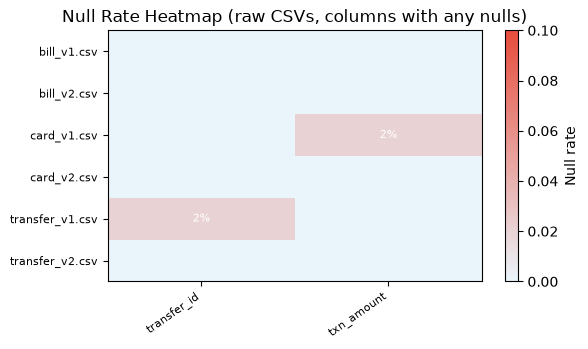

In [37]:
# Heatmap — only show columns that have at least one non-zero null rate
cols_with_nulls = null_df.columns[(null_df > 0).any()]
plot_df = null_df[cols_with_nulls] if len(cols_with_nulls) else null_df.iloc[:, :5]

fig, ax = plt.subplots(figsize=(max(6, len(plot_df.columns) * 1.2), max(3, len(plot_df) * 0.6)))
cmap = mcolors.LinearSegmentedColormap.from_list("nullmap", ["#eaf4fb", "#e74c3c"])
im = ax.imshow(plot_df.values, aspect="auto", cmap=cmap, vmin=0, vmax=0.1)
ax.set_xticks(range(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8)
ax.set_title("Null Rate Heatmap (raw CSVs, columns with any nulls)")
for i in range(len(plot_df)):
    for j in range(len(plot_df.columns)):
        val = plot_df.values[i, j]
        if val > 0:
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8, color="white")
plt.colorbar(im, ax=ax, label="Null rate")
plt.tight_layout()
plt.show()

### 3c — Amount Outliers (Z-Score)

In [38]:
Z_THRESHOLD = 3.0

amounts = df_valid[["payment_id", "payment_method", "amount_cents"]].copy()
stats   = amounts.groupby("payment_method")["amount_cents"].agg(["mean", "std"]).reset_index()
amounts = amounts.merge(stats, on="payment_method")
amounts["z"] = (amounts["amount_cents"] - amounts["mean"]) / amounts["std"]

outliers = amounts[amounts["z"].abs() > Z_THRESHOLD].sort_values("z", ascending=False)

if outliers.empty:
    print("No amount outliers detected (|z| > 3.0).")
else:
    print(f"AMOUNT OUTLIERS (|z| > {Z_THRESHOLD}):")
    for _, r in outliers.iterrows():
        print(f"  {r['payment_id']} | {r['payment_method']} | "
              f"${r['amount_cents']/100:.2f} | z={r['z']:.2f}")

No amount outliers detected (|z| > 3.0).


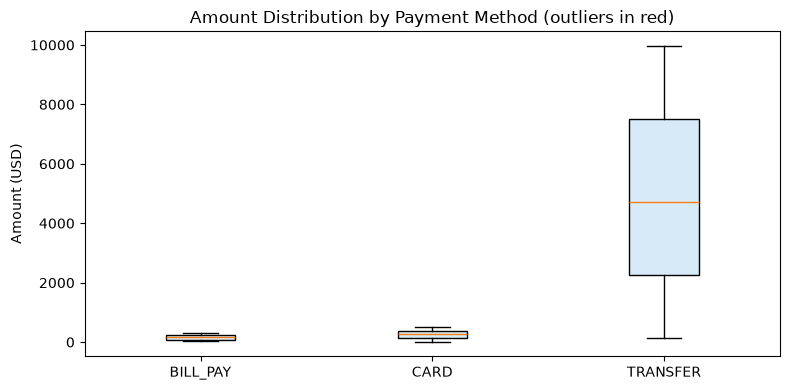

In [39]:
methods = sorted(df_valid["payment_method"].unique())
data_by_method = [df_valid.loc[df_valid["payment_method"] == m, "amount_cents"].values / 100
                  for m in methods]

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(data_by_method, patch_artist=True,
                flierprops=dict(marker="o", color="#e74c3c", markersize=5))
ax.set_xticks(range(1, len(methods) + 1))
ax.set_xticklabels(methods)
for patch in bp["boxes"]:
    patch.set_facecolor("#d6eaf8")
ax.set_ylabel("Amount (USD)")
ax.set_title("Amount Distribution by Payment Method (outliers in red)")
plt.tight_layout()
plt.show()